# 02 · Exploração e teste da hipótese

**Hipótese:** crime e preço de imóvel têm correlação negativa — bairro mais violento, metro quadrado mais barato.

Este notebook carrega os parquets preparados em `01_preparacao.ipynb`, converte os valores para **reais constantes pelo IPCA oficial**, junta as duas bases pelo gazetteer de ruas, explora cada lado separadamente e termina medindo a correlação no nível de bairro.

A conclusão quantitativa está na seção 8. A seção 10 lista o que pode estar distorcendo o resultado.

In [1]:
import gzip
import json
import re
import unicodedata
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
from scipy import stats

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
CACHE = RAIZ / "data" / "SP" / "cache"

crimes = pd.read_parquet(CACHE / "crimes_sp.parquet")
itbi = pd.read_parquet(CACHE / "itbi_sp.parquet")
gazetteer = pd.read_parquet(CACHE / "gazetteer_ruas.parquet")

print(f"crimes    {len(crimes):>9,} ocorrências")
print(f"itbi      {len(itbi):>9,} transações")
print(f"gazetteer {len(gazetteer):>9,} ruas")

crimes    2,214,258 ocorrências
itbi        943,536 transações
gazetteer    48,214 ruas


### Estilo dos gráficos

Paleta fixa para os três notebooks, com uma regra por trás de cada escolha:

- **Azul** é a cor padrão de série única; laranja e aqua entram só quando há mais de uma série. A ordem é fixa, nunca ciclada.
- **Magnitude** (mapas de calor, quintis) usa rampa de **uma só cor** clara→escura — nunca arco-íris, porque arco-íris não tem ordem perceptual.
- **Crime e preço têm rampas de cores diferentes** (azul e laranja) justamente para o leitor não confundir as duas escalas quando elas aparecem lado a lado.
- **Polaridade** (matriz de correlação, que vai de −1 a +1) usa rampa divergente azul↔vermelho com **cinza no meio**, para o zero não parecer um valor.

In [2]:
AZUL, LARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SUPERFICIE, TINTA, TINTA2, MUDO, GRADE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

RAMPA_CRIME = LinearSegmentedColormap.from_list("crime", ["#cde2fb", "#5598e7", "#256abf", "#0d366b"])
RAMPA_PRECO = LinearSegmentedColormap.from_list("preco", ["#fde8dc", "#f29b70", "#eb6834", "#8f3414"])
DIVERGENTE = LinearSegmentedColormap.from_list("div", [AZUL, "#f0efec", "#e34948"])
ESCADA_AZUL = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "figure.dpi": 110, "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"], "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.labelcolor": TINTA2, "axes.labelsize": 10,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRADE, "grid.linewidth": 0.8,
    "xtick.color": MUDO, "ytick.color": MUDO, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "lines.linewidth": 2, "lines.markersize": 8,
})
sns.set_palette([AZUL, LARANJA, AQUA])


def reais(valor, _=None):
    return f"R$ {valor:,.0f}".replace(",", ".")


FORMATO_REAIS = FuncFormatter(reais)

## 1 · Deflacionando para reais constantes

A base cobre de 2022 a 2026. Nesse intervalo o real perdeu poder de compra, então um apartamento vendido por R$ 500 mil em 2022 e outro vendido por R$ 500 mil em 2026 **não custaram a mesma coisa**. Sem corrigir isso, parte da variação de preço que o modelo vê é só inflação, e um bairro cujas vendas se concentram nos anos recentes pareceria mais caro do que é.

A correção usa o **IPCA oficial**, baixado direto da API de agregados do **IBGE** — que é quem produz o índice, não um redistribuidor. Tabela 1737, duas variáveis:

- **2266** — número-índice (base dezembro de 1993 = 100)
- **63** — variação percentual mensal

Nada aqui é taxa estimada ou arredondada. A série é salva em `data/SP/cache/ipca_ibge.csv` na primeira execução, então o notebook roda offline depois.

**Por que usar o número-índice e não encadear as variações:** encadear 60 multiplicações de valores já arredondados a duas casas acumula erro. O número-índice é o nível de preços publicado, e o fator de correção sai de uma única divisão: `índice do mês de referência ÷ índice do mês da transação`. O mês de referência é o último da série, então todos os valores ficam em reais de hoje.

**A tabela de verificação** ao final da célula é o controle de qualidade. Ela calcula o IPCA acumulado de cada ano por dois caminhos independentes — razão entre números-índice de dezembro, e produto das variações mensais. Se os dois concordam, a série foi lida corretamente (sem vírgula virando separador de milhar, sem mês fora de ordem). E os valores são publicados pelo IBGE, logo conferíveis por fora.

In [3]:
URL_IPCA = (
    "https://servicodados.ibge.gov.br/api/v3/agregados/1737"
    "/periodos/202101-202612/variaveis/2266|63?localidades=N1[all]"
)
ARQUIVO_IPCA = CACHE / "ipca_ibge.csv"
VARIAVEIS_IPCA = {"2266": "indice", "63": "variacao_pct"}


def baixa_ipca():
    pedido = urllib.request.Request(URL_IPCA, headers={"Accept-Encoding": "identity"})
    with urllib.request.urlopen(pedido, timeout=60) as resposta:
        conteudo = resposta.read()
    if conteudo[:2] == b"\x1f\x8b":
        conteudo = gzip.decompress(conteudo)
    bruto = json.loads(conteudo.decode("utf-8"))
    series = {
        VARIAVEIS_IPCA[v["id"]]: v["resultados"][0]["series"][0]["serie"] for v in bruto
    }
    return pd.DataFrame(series).rename_axis("periodo").reset_index()


def carrega_ipca():
    if ARQUIVO_IPCA.exists():
        print(f"IPCA: lendo de {ARQUIVO_IPCA.name}")
        tabela = pd.read_csv(ARQUIVO_IPCA, dtype={"periodo": str})
    else:
        tabela = baixa_ipca()
        tabela.to_csv(ARQUIVO_IPCA, index=False)
        print(f"IPCA: baixado da API do IBGE (tabela 1737) e salvo em {ARQUIVO_IPCA.name}")
    for coluna in VARIAVEIS_IPCA.values():
        tabela[coluna] = pd.to_numeric(tabela[coluna], errors="coerce")
    tabela["mes"] = tabela["periodo"].str[:4] + "-" + tabela["periodo"].str[4:]
    return tabela.dropna(subset=["indice"]).sort_values("mes").reset_index(drop=True)


ipca = carrega_ipca()
ipca["fator"] = ipca["indice"].iloc[-1] / ipca["indice"]
MES_REFERENCIA = ipca["mes"].iloc[-1]

print(f"Série oficial: {len(ipca)} meses, de {ipca['mes'].iloc[0]} a {MES_REFERENCIA}")
print(f"Reais constantes de: {MES_REFERENCIA}")
print(f"Fator no mês mais antigo ({ipca['mes'].iloc[0]}): {ipca['fator'].iloc[0]:.4f}\n")

anual = ipca.assign(ano=ipca["mes"].str[:4]).groupby("ano").agg(
    meses=("variacao_pct", "size"),
    indice_dez=("indice", "last"),
    por_encadeamento=("variacao_pct", lambda v: ((1 + v / 100).prod() - 1) * 100),
)
anual["por_numero_indice"] = (anual["indice_dez"] / anual["indice_dez"].shift() - 1) * 100
anual["diferença"] = anual["por_encadeamento"] - anual["por_numero_indice"]

anual[["meses", "por_encadeamento", "por_numero_indice", "diferença"]].style.format(
    {"por_encadeamento": "{:.2f}%", "por_numero_indice": "{:.2f}%", "diferença": "{:+.3f} pp"},
    na_rep="—",
).set_caption("IPCA acumulado por ano, calculado de duas formas independentes")

IPCA: lendo de ipca_ibge.csv
Série oficial: 68 meses, de 2021-01 a 2026-08
Reais constantes de: 2026-08
Fator no mês mais antigo (2021-01): 1.3693



,meses,por_encadeamento,por_numero_indice,diferença
ano,,,,
2021,12,10.06%,—,—
2022,12,5.78%,5.79%,-0.000 pp
2023,12,4.62%,4.62%,-0.000 pp
2024,12,4.83%,4.83%,+0.000 pp
2025,12,4.26%,4.26%,+0.000 pp
2026,8,3.11%,3.11%,-0.000 pp


## 2 · Agrupando as 24 naturezas criminais

A SSP-SP classifica as ocorrências em 24 naturezas. Para a hipótese, o que interessa é separar o que de fato sinaliza insegurança para quem mora ali.

A ordem das regras importa: `HOMICÍDIO CULPOSO POR ACIDENTE DE TRÂNSITO` e `LESÃO CORPORAL CULPOSA POR ACIDENTE DE TRÂNSITO` contêm as palavras "homicídio" e "lesão corporal", mas são acidentes de trânsito — contá-los como violência mediria fluxo de carros, não criminalidade. Por isso trânsito e culposos são capturados **primeiro**.

A distinção entre **violento** (roubo, com vítima presente) e **patrimonial sem violência** (furto, sem contato) é o eixo central da análise: furto se concentra onde há muita gente circulando, roubo se concentra onde há risco.

In [4]:
VIOLENTOS = ("ROUBO", "LATROCINIO", "HOMICIDIO", "LESAO CORPORAL", "ESTUPRO", "EXTORSAO", "SEQUESTRO")


def grupo_crime(natureza):
    if "ACIDENTE DE TRANSITO" in natureza or "CULPOS" in natureza:
        return "trânsito / culposo"
    if natureza.startswith("FURTO"):
        return "patrimonial sem violência"
    if any(termo in natureza for termo in VIOLENTOS):
        return "violento"
    return "outros"


crimes["grupo"] = crimes["natureza"].astype(str).map(grupo_crime)

(
    crimes.groupby(["grupo", "natureza"], observed=True)
    .size()
    .rename("ocorrências")
    .reset_index()
    .sort_values(["grupo", "ocorrências"], ascending=[True, False])
    .set_index(["grupo", "natureza"])
)

ocorrências
grupo                     natureza                                                    
outros                    TRAFICO DE ENTORPECENTES                               22998
                          PORTE DE ENTORPECENTES                                  4247
                          APREENSAO DE ENTORPECENTES                              4014
                          PORTE DE ARMA                                           3883
patrimonial sem violência FURTO - OUTROS                                       1129990
                          FURTO DE VEICULO                                      187010
                          FURTO DE CARGA                                           680
trânsito / culposo        LESAO CORPORAL CULPOSA POR ACIDENTE DE TRANSITO        62539
                          LESAO CORPORAL CULPOSA - OUTRAS                         2756
                          HOMICIDIO CULPOSO POR ACIDENTE DE TRANSITO              2655
                          LESAO CORPORAL CULPOSA  OUTRAS                           674
                          HOMICIDIO CULPOSO OUTROS                                 115
                          HOMICIDIO DOLOSO POR ACIDENTE DE TRANSITO                 39
violento                  ROUBO - OUTROS                                        534361
                          LESAO CORPORAL DOLOSA                                 170581
                          ROUBO DE VEICULO                                       58276
                          ROUBO DE CARGA                                         10649
                          ESTUPRO DE VULNERAVEL                                   9224
                          ESTUPRO                                                 3331
                          TENTATIVA DE HOMICIDIO                                  3145
                          HOMICIDIO DOLOSO                                        2277
                          EXTORSAO MEDIANTE SEQUESTRO                              452
                          LATROCINIO                                               217
                          LESAO CORPORAL SEGUIDA DE MORTE                          130
                          ROUBO A BANCO                                             15

## 3 · Localizando cada transação

O ITBI não traz coordenada e seu campo `Bairro` só está preenchido em 61% das linhas. A primeira versão desta análise usava apenas o gazetteer de ruas, e isso produziu um erro visível: **`RUA MELO ALVES` existe duas vezes em São Paulo** — nos Jardins e no Jardim Monte Verde, na zona sul. O crime nunca foi registrado na Melo Alves dos Jardins (só 9 ocorrências na cidade inteira, todas na do sul), então o gazetteer conhecia apenas a versão periférica e etiquetou 255 transações de apartamento dos Jardins como se fossem do Jardim Monte Verde. O resultado: o bairro mais caro da cidade aparecia com R$ 11,2 mil/m² *e* 57% de crimes violentos — combinação impossível, e o sinal de que havia um bug.

O problema não é ambiguidade de nome, é **evidência rala**: confiar o destino de 542 transações a um nome de rua visto 9 vezes. A correção usa três fontes, em ordem de confiabilidade:

| prioridade | fonte | cobertura | por que nessa ordem |
|---|---|---|---|
| 1ª | **campo `Bairro` do próprio ITBI** | 38,8% | vem do cadastro do IPTU, é a fonte oficial do endereço |
| 2ª | **propagação por CEP** | 92,6% | CEP em São Paulo é quase quadra; o bairro é propagado dos registros confiáveis do mesmo CEP |
| 3ª | **gazetteer de ruas** (≥ 20 ocorrências) | 79,8% | só para o que sobrou, e exigindo evidência mínima |
| | **combinado** | **97,0%** | |

A propagação por CEP sozinha já supera o gazetteer, e usa a geografia postal da cidade em vez do acaso de onde houve ocorrência policial. O `Bairro` do ITBI é normalizado (acentos, abreviações) e só é aceito se existir no vocabulário de bairros dos crimes — caso contrário não haveria com o que cruzar a taxa de criminalidade.

**Coordenada:** continua vindo do gazetteer, que é a única fonte de lat/long, mas só é aceita quando o bairro modal da rua **concorda** com o bairro final da transação. Quando discordam, usa-se o centro do bairro. Isso evita o caso Melo Alves aparecer nos mapas com o bairro correto e a coordenada errada.

In [5]:
ABREVIACOES_BAIRRO = {
    "VL": "VILA", "JD": "JARDIM", "PQ": "PARQUE", "CJ": "CONJUNTO", "CID": "CIDADE",
    "S": "SAO", "STO": "SANTO", "STA": "SANTA", "CH": "CHACARA", "AL": "ALTO",
}
VOCABULARIO_BAIRROS = set(crimes["bairro"].dropna().astype(str).unique())
MINIMO_OCORRENCIAS_RUA = 20


def normaliza_bairro(nome):
    texto = unicodedata.normalize("NFKD", str(nome)).encode("ascii", "ignore").decode().upper()
    palavras = re.sub(r"[^A-Z0-9 ]", " ", texto).split()
    return " ".join(ABREVIACOES_BAIRRO.get(p, p) for p in palavras) or None


def bairro_por_cep(tabela):
    return (
        tabela.dropna(subset=["bairro_declarado"])
        .groupby(["cep_txt", "bairro_declarado"])
        .size()
        .rename("n")
        .reset_index()
        .sort_values("n")
        .groupby("cep_txt")["bairro_declarado"]
        .last()
        .rename("bairro_cep")
    )


def centro_dos_bairros():
    centro = (
        crimes.dropna(subset=["lat", "lon"])
        .groupby("bairro", observed=True)[["lat", "lon"]]
        .median()
    )
    centro.index = centro.index.astype(str)
    return centro


def localiza(transacoes):
    traduzido = {v: normaliza_bairro(v) for v in transacoes["bairro_itbi"].dropna().unique()}
    tabela = transacoes.assign(
        cep_txt=transacoes["cep"].astype("Int64").astype(str).str.zfill(8),
        bairro_declarado=transacoes["bairro_itbi"].map(traduzido),
    )
    tabela["bairro_declarado"] = tabela["bairro_declarado"].where(
        tabela["bairro_declarado"].isin(VOCABULARIO_BAIRROS)
    )

    ruas_confiaveis = gazetteer[gazetteer["n_ocorrencias"] >= MINIMO_OCORRENCIAS_RUA]
    tabela = tabela.join(bairro_por_cep(tabela), on="cep_txt")
    tabela["bairro_rua"] = tabela["rua_key"].map(
        ruas_confiaveis.set_index("rua_key")["bairro"].astype(str)
    )
    tabela["bairro"] = (
        tabela["bairro_declarado"].fillna(tabela["bairro_cep"]).fillna(tabela["bairro_rua"])
    )

    centro = centro_dos_bairros()
    tabela = tabela.join(gazetteer.set_index("rua_key")[["lat", "lon"]], on="rua_key")
    rua_concorda = tabela["bairro_rua"].eq(tabela["bairro"])
    for eixo in ["lat", "lon"]:
        tabela[eixo] = tabela[eixo].where(rua_concorda, tabela["bairro"].map(centro[eixo]))

    cobertura = {
        "campo Bairro do ITBI": tabela["bairro_declarado"].notna().mean(),
        "propagação por CEP": tabela["bairro_cep"].notna().mean(),
        "gazetteer de ruas": tabela["bairro_rua"].notna().mean(),
        "combinado": tabela["bairro"].notna().mean(),
    }
    return tabela.drop(columns=["cep_txt", "bairro_declarado", "bairro_cep", "bairro_rua"]), cobertura


itbi, cobertura_bairro = localiza(itbi)

print(f"coordenada disponível em {itbi['lat'].notna().mean():.1%} das transações")
print("\nchecagem do caso que motivou a correção — RUA MELO ALVES:")
print(itbi[itbi["rua_key"] == "MELO ALVES"]["bairro"].value_counts().head(4).to_string())

pd.Series(cobertura_bairro, name="cobertura").to_frame().style.format({"cobertura": "{:.1%}"})

coordenada disponível em 96.7% das transações

checagem do caso que motivou a correção — RUA MELO ALVES:
bairro
CERQUEIRA CESAR    513
JARDIM AMERICA      29
JARDIM PAULISTA      2
JARDINS              2


,cobertura
campo Bairro do ITBI,38.9%
propagação por CEP,92.6%
gazetteer de ruas,79.8%
combinado,97.0%


## 4 · Filtros: de guia de ITBI a preço real por metro quadrado

Nem toda guia de ITBI é uma venda de imóvel residencial comparável. O funil abaixo mostra quanto cada regra custa em volume. Quatro delas merecem explicação:

**`transação entre 2022 e 2026`** — a `data de transação` é a data da escritura, não a do pagamento da guia. A base traz escrituras desde **1994**, registradas tarde. São 0,7% das linhas, mas precisam sair: não há dado de crime antes de 2022 para pareá-las, e um preço de 1994 não é comparável nem após deflação.

**`proporção transmitida = 100%`** é o filtro mais caro (descarta quase metade) e o mais importante. Quando a proporção é menor, a transação é uma **fração ideal de um lote-matriz** — por exemplo 0,01% de um terreno de condomínio. Nesses casos a `área construída` da linha é a do prédio inteiro, não a do apartamento vendido, e `valor ÷ área` daria um número sem sentido. Checagem que confirma a leitura: `vvr_proporcional ÷ vvr` é sempre igual a `proporção ÷ 100`, ou seja, o campo é percentual e o `0,01` é literalmente um centésimo de por cento.

**Exclusão de vagas de garagem**: vagas autônomas em prédios residenciais têm padrão `RESIDENCIAL VERTICAL` e poucos metros quadrados, o que infla artificialmente o R$/m² do bairro.

**`mês coberto pela série do IPCA`**: o IPCA é publicado com defasagem, então os meses mais recentes da base de ITBI podem não ter índice ainda. Em vez de inventar um fator para eles, essas transações são descartadas e a contagem fica registrada no funil.

In [6]:
MESES_COM_IPCA = set(ipca["mes"])

FILTROS = [
    ("guias de ITBI (tudo)", lambda d: d),
    ("transação entre 2022 e 2026", lambda d: d[d["ano"].between(2022, 2026)]),
    ("natureza = compra e venda", lambda d: d[d["natureza_transacao"].astype(str).str.startswith("1.")]),
    ("100% do imóvel transmitido", lambda d: d[d["proporcao_transmitida"] == 100]),
    ("padrão residencial", lambda d: d[d["padrao_desc"].astype(str).str.startswith("RESIDENCIAL")]),
    ("exclui vaga de garagem", lambda d: d[~d["uso_desc"].astype(str).str.contains("GARAGEM")]),
    ("área construída e valor > 0", lambda d: d[d["area_construida"].gt(0) & d["valor_transacao"].gt(0)]),
    ("bairro identificado", lambda d: d[d["bairro"].notna()]),
    ("mês coberto pela série do IPCA", lambda d: d[d["mes"].isin(MESES_COM_IPCA)]),
]

base = itbi
funil = []
for nome, filtro in FILTROS:
    base = filtro(base)
    funil.append((nome, len(base)))

base = base.merge(ipca[["mes", "fator"]], on="mes", how="left")

base["valor_real"] = base["valor_transacao"] * base["fator"]
base["preco_m2_nominal"] = base["valor_transacao"] / base["area_construida"]
base["preco_m2"] = base["valor_real"] / base["area_construida"]

base = base[base["preco_m2"].between(*base["preco_m2"].quantile([0.01, 0.99]))]
funil.append(("R$/m² real entre os percentis 1 e 99", len(base)))

base["idade"] = base["ano"] - base["acc"].where(base["acc"].between(1800, 2026))

assert base["fator"].notna().all(), "transação sem fator de deflação"
assert base["bairro"].notna().all(), "transação sem bairro"

funil = pd.DataFrame(funil, columns=["filtro", "linhas"])
funil["% do total"] = funil["linhas"] / funil.loc[0, "linhas"]
funil["perda no passo"] = funil["linhas"].diff().fillna(0)
funil.style.format({
    "linhas": "{:,.0f}", "% do total": "{:.1%}", "perda no passo": "{:,.0f}",
}).hide(axis="index")

filtro,linhas,% do total,perda no passo
guias de ITBI (tudo),"943,536",100.0%,0
transação entre 2022 e 2026,"936,935",99.3%,"-6,601"
natureza = compra e venda,"845,414",89.6%,"-91,521"
100% do imóvel transmitido,"460,864",48.8%,"-384,550"
padrão residencial,"407,264",43.2%,"-53,600"
exclui vaga de garagem,"373,297",39.6%,"-33,967"
área construída e valor > 0,"373,296",39.6%,-1
bairro identificado,"360,922",38.3%,"-12,374"
mês coberto pela série do IPCA,"360,769",38.2%,-153
R$/m² real entre os percentis 1 e 99,"353,553",37.5%,"-7,216"


### Quanto a deflação muda o retrato

A comparação abaixo é a razão de ter feito isso. A série nominal mistura valorização real com inflação; a série deflacionada mostra só o que sobrou de valorização em poder de compra.

Variação do R$/m² mediano de 2022-01 a 2026-08:
  nominal ....... +22.6%
  real (IPCA) ... -1.2%


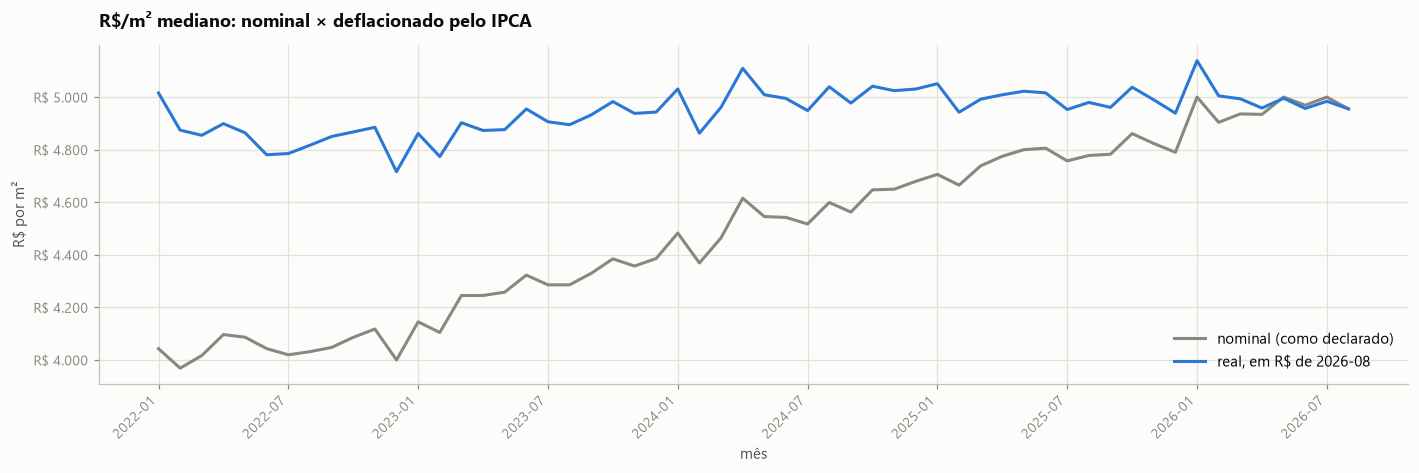

In [7]:
comparativo = base.groupby("mes").agg(nominal=("preco_m2_nominal", "median"),
                                      real=("preco_m2", "median"))

fig, eixo = plt.subplots(figsize=(13, 4.4))
eixo.plot(comparativo.index, comparativo["nominal"], color=MUDO, label="nominal (como declarado)")
eixo.plot(comparativo.index, comparativo["real"], color=AZUL,
          label=f"real, em R$ de {MES_REFERENCIA}")
eixo.set(title="R$/m² mediano: nominal × deflacionado pelo IPCA", xlabel="mês", ylabel="R$ por m²")
eixo.yaxis.set_major_formatter(FORMATO_REAIS)
eixo.set_xticks(eixo.get_xticks()[::6])
plt.setp(eixo.get_xticklabels(), rotation=45, ha="right")
eixo.legend(loc="lower right")
plt.tight_layout()

primeiro, ultimo = comparativo.index[0], comparativo.index[-1]
variacao = comparativo.loc[[primeiro, ultimo]].pct_change().iloc[-1] * 100
print(f"Variação do R$/m² mediano de {primeiro} a {ultimo}:")
print(f"  nominal ....... {variacao['nominal']:+.1f}%")
print(f"  real (IPCA) ... {variacao['real']:+.1f}%")

**Daqui para frente, `preco_m2` é sempre o valor real** — em reais constantes do mês de referência. A coluna nominal fica guardada apenas para comparações como a de cima.

## 5 · O lado imóvel

Três perguntas de sanidade antes de qualquer correlação: o preço tem distribuição bem comportada? o volume de transações é estável no tempo? os tipos de imóvel têm preços distintos?

count    353,553
mean       5,434
std        2,713
min           37
25%        3,601
50%        4,948
75%        6,712
max       18,676


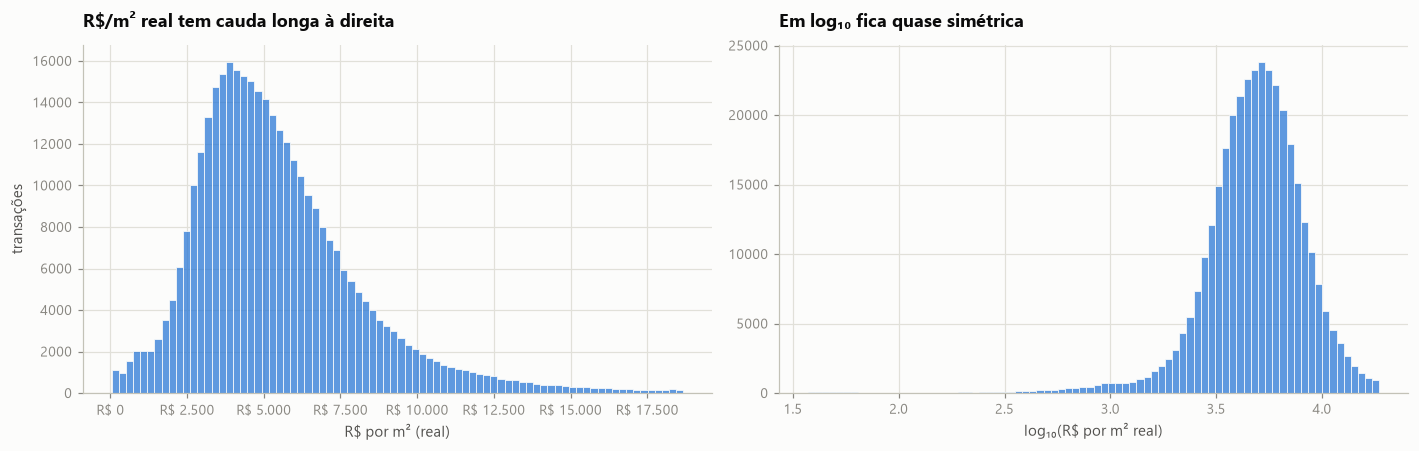

In [8]:
fig, (esq, drt) = plt.subplots(1, 2, figsize=(13, 4.2))

sns.histplot(base["preco_m2"], bins=80, color=AZUL, ax=esq, edgecolor=SUPERFICIE, linewidth=0.5)
esq.set(title="R$/m² real tem cauda longa à direita", xlabel="R$ por m² (real)", ylabel="transações")
esq.xaxis.set_major_formatter(FORMATO_REAIS)

sns.histplot(np.log10(base["preco_m2"]), bins=80, color=AZUL, ax=drt, edgecolor=SUPERFICIE, linewidth=0.5)
drt.set(title="Em log₁₀ fica quase simétrica", xlabel="log₁₀(R$ por m² real)", ylabel="")

plt.tight_layout()

print(base["preco_m2"].describe().apply(lambda v: f"{v:,.0f}").to_string())

A cauda longa é esperada em preço de imóvel e é a razão pela qual o modelo do notebook 03 prevê **log do preço**: em escala logarítmica os resíduos ficam bem comportados, e o coeficiente passa a ser lido como variação percentual.

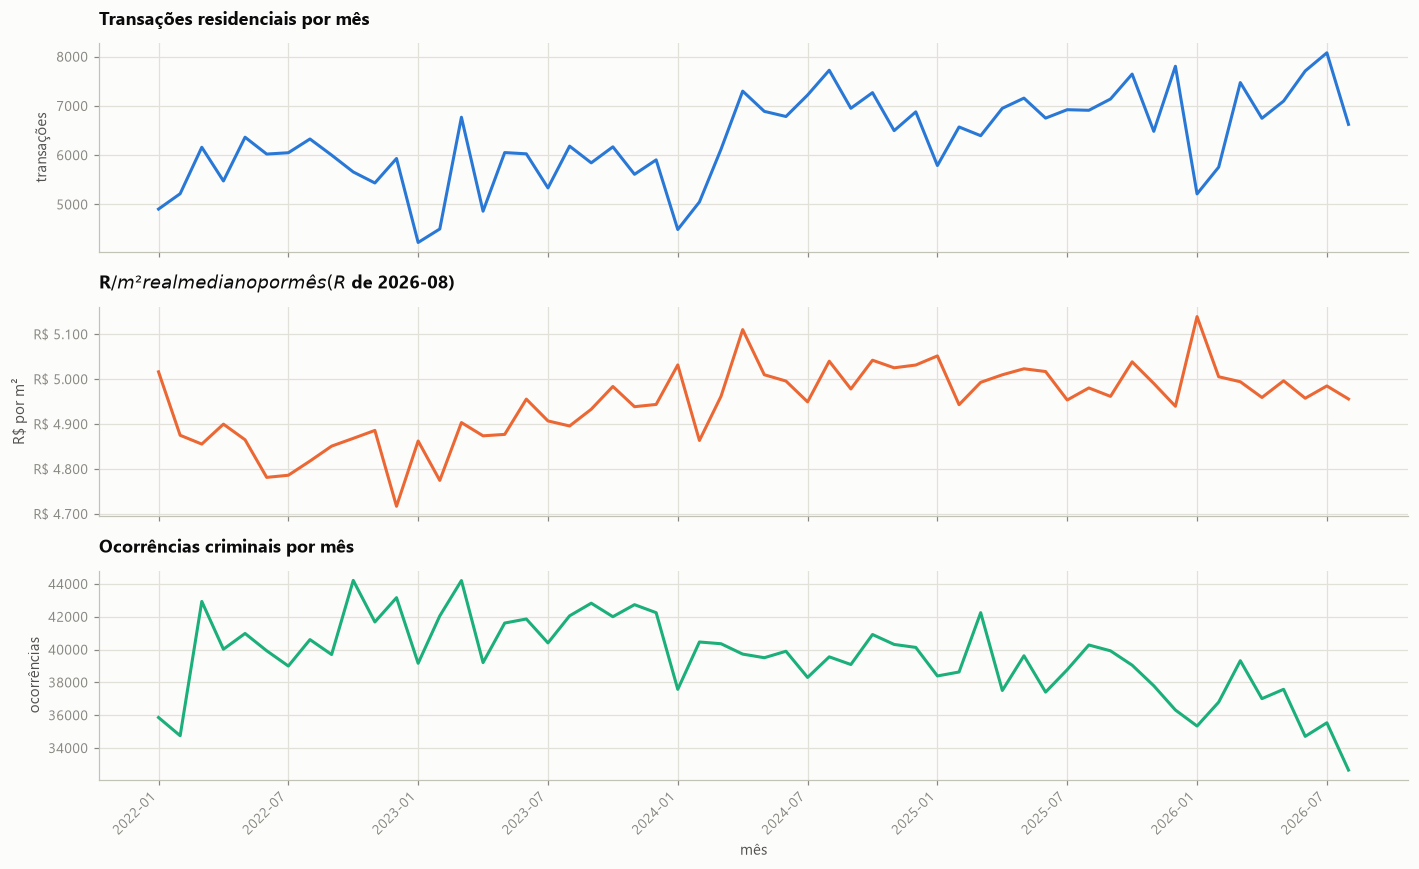

In [9]:
por_mes = base.groupby("mes").agg(transacoes=("preco_m2", "size"), preco_mediano=("preco_m2", "median"))
crimes_mes = crimes.groupby("mes").size()

fig, eixos = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

eixos[0].plot(por_mes.index, por_mes["transacoes"], color=AZUL)
eixos[0].set(title="Transações residenciais por mês", ylabel="transações")

eixos[1].plot(por_mes.index, por_mes["preco_mediano"], color=LARANJA)
eixos[1].set(title=f"R$/m² real mediano por mês (R$ de {MES_REFERENCIA})", ylabel="R$ por m²")
eixos[1].yaxis.set_major_formatter(FORMATO_REAIS)

eixos[2].plot(crimes_mes.index, crimes_mes.to_numpy(), color=AQUA)
eixos[2].set(title="Ocorrências criminais por mês", ylabel="ocorrências", xlabel="mês")

eixos[2].set_xticks(eixos[2].get_xticks()[::6])
plt.setp(eixos[2].get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()

Três painéis empilhados em vez de um gráfico com dois eixos y: duas escalas no mesmo gráfico permitem "escolher" uma correlação visual só mexendo nos limites dos eixos. Painéis separados que compartilham o eixo do tempo mostram a mesma informação sem esse truque.

A queda no fim das séries é artefato de ano parcial — os dados de 2026 não cobrem o ano inteiro. Por isso as taxas anuais de crime usadas na correlação são calculadas apenas sobre **2022–2025**, os quatro anos completos.

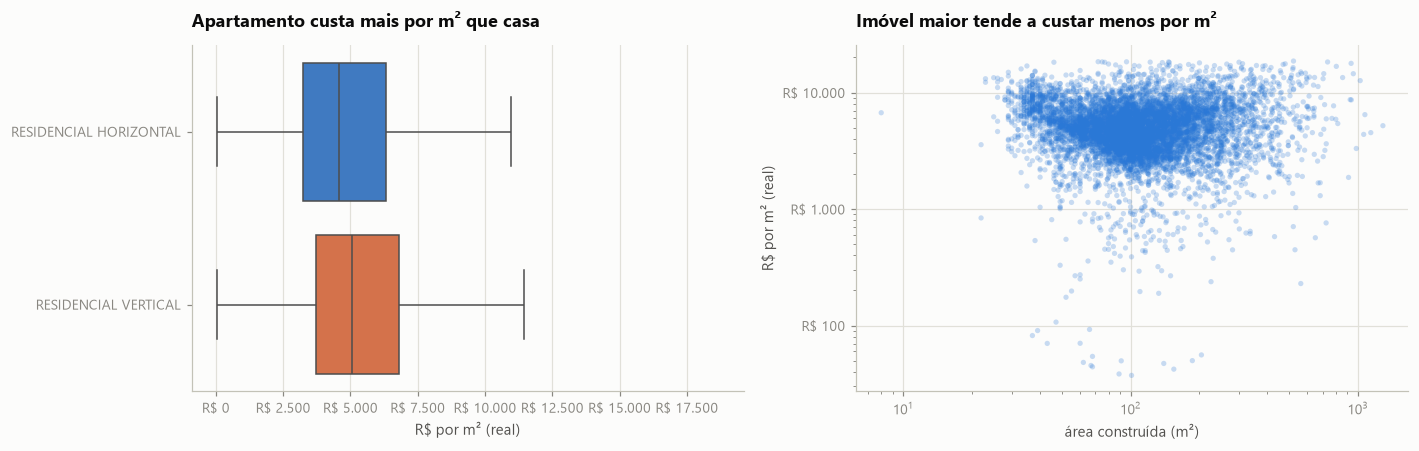

In [10]:
base["tipo"] = base["padrao_desc"].astype(str).str.strip()
recorte = base[base["tipo"].isin(base["tipo"].value_counts().index[:2])]

fig, (esq, drt) = plt.subplots(1, 2, figsize=(13, 4.2))

sns.boxplot(data=recorte, y="tipo", x="preco_m2", hue="tipo", palette=[AZUL, LARANJA],
            legend=False, fliersize=0, linewidth=1, ax=esq)
esq.set(title="Apartamento custa mais por m² que casa", xlabel="R$ por m² (real)", ylabel="")
esq.xaxis.set_major_formatter(FORMATO_REAIS)

sns.scatterplot(data=base.sample(8000, random_state=42), x="area_construida", y="preco_m2",
                color=AZUL, alpha=0.25, s=12, edgecolor="none", ax=drt)
drt.set(title="Imóvel maior tende a custar menos por m²", xlabel="área construída (m²)",
        ylabel="R$ por m² (real)", xscale="log", yscale="log")
drt.yaxis.set_major_formatter(FORMATO_REAIS)

plt.tight_layout()

## 6 · O lado crime

Qual é a composição das ocorrências e onde elas se concentram.

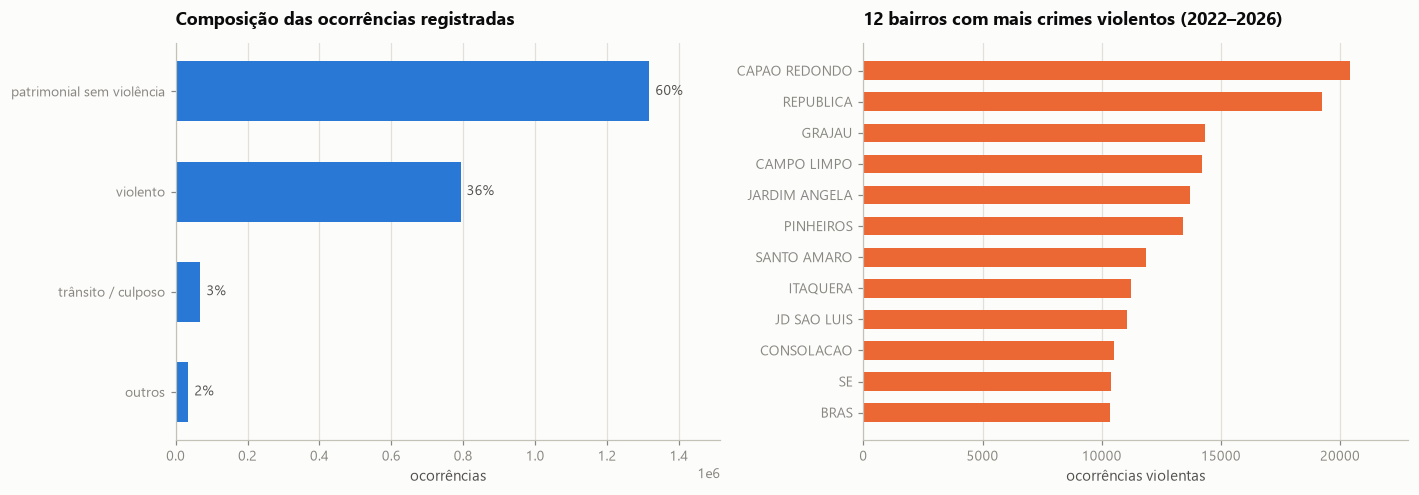

In [11]:
fig, (esq, drt) = plt.subplots(1, 2, figsize=(13, 4.6))

por_grupo = crimes["grupo"].value_counts()
barras = esq.barh(por_grupo.index[::-1], por_grupo.to_numpy()[::-1], color=AZUL, height=0.6)
esq.bar_label(barras, labels=[f"{v / len(crimes):.0%}" for v in por_grupo.to_numpy()[::-1]],
              padding=4, color=TINTA2, fontsize=9)
esq.set(title="Composição das ocorrências registradas", xlabel="ocorrências")
esq.margins(x=0.15)
esq.grid(axis="y", visible=False)

top = crimes[crimes["grupo"] == "violento"]["bairro"].value_counts().head(12)
drt.barh(top.index[::-1].astype(str), top.to_numpy()[::-1], color=LARANJA, height=0.6)
drt.set(title="12 bairros com mais crimes violentos (2022–2026)", xlabel="ocorrências violentas")
drt.margins(x=0.12)
drt.grid(axis="y", visible=False)

plt.tight_layout()

Esse ranking já mostra o problema que a análise precisa enfrentar: os bairros do topo são os do centro e os grandes polos comerciais — lugares com enorme circulação de pessoas, não necessariamente onde é pior morar. Contagem bruta de crime mede em parte **exposição**, não só risco. É por isso que a seção 8 testa quatro medidas diferentes de crime, não só a contagem.

## 7 · Os dois mapas

Como as transações herdaram uma coordenada — da rua quando ela é confiável, do centro do bairro quando não —, crime e preço podem ser desenhados na mesma projeção, hexágono por hexágono. Nenhum shapefile foi necessário.

Cada hexágono do mapa da esquerda conta ocorrências (escala log, porque o centro concentra ordens de magnitude mais). Cada hexágono da direita traz a **mediana** do R$/m² real das transações que caíram nele, exigindo pelo menos 10 transações para não desenhar hexágono baseado em uma venda só.

Se a hipótese valer na forma ingênua, as manchas escuras de um mapa cairiam sobre as manchas claras do outro. Compare com atenção — o resultado da seção 9 explica por que não é isso que se vê.

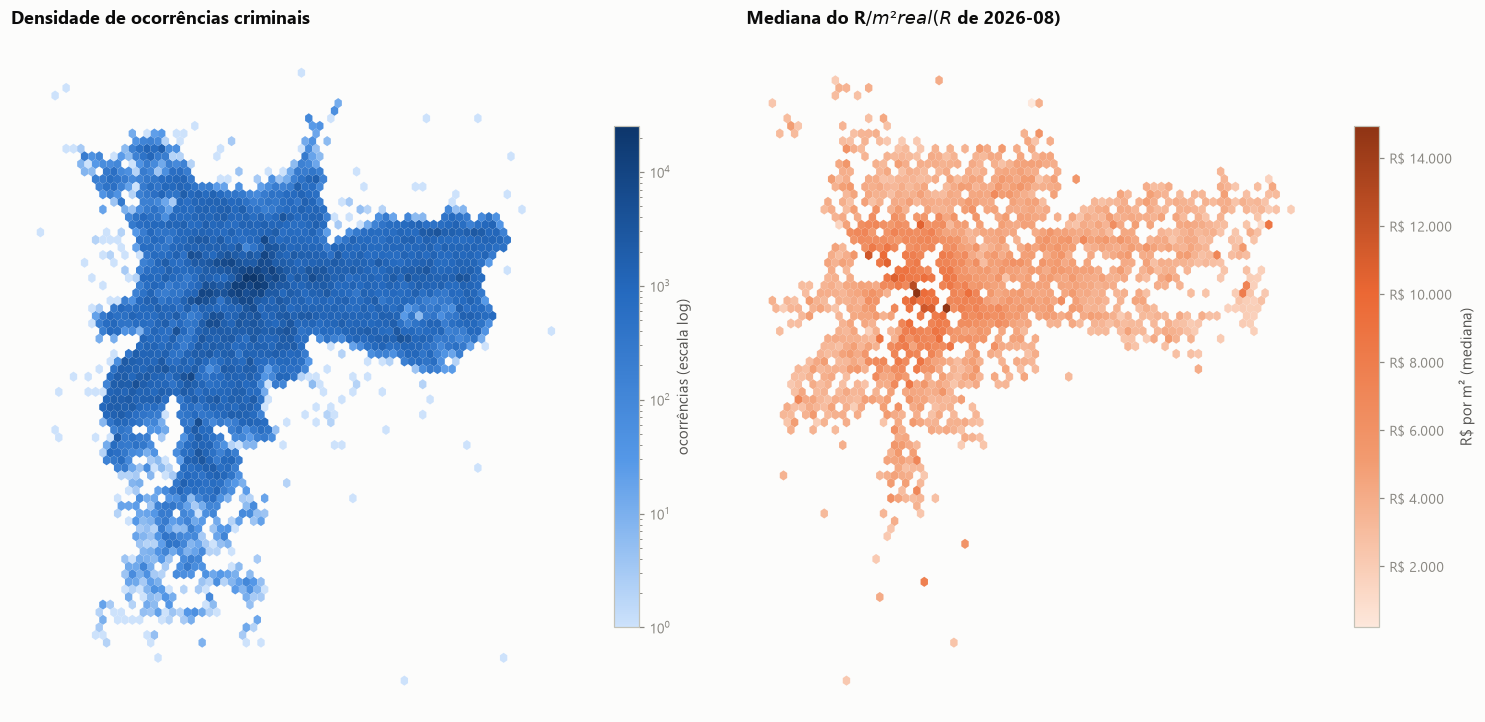

In [12]:
geo_crimes = crimes.dropna(subset=["lat", "lon"])
geo_base = base.dropna(subset=["lat", "lon"])

fig, (esq, drt) = plt.subplots(1, 2, figsize=(14, 6.5))

mapa_crime = esq.hexbin(geo_crimes["lon"], geo_crimes["lat"], gridsize=70,
                        bins="log", cmap=RAMPA_CRIME, linewidths=0)
esq.set_title("Densidade de ocorrências criminais")
fig.colorbar(mapa_crime, ax=esq, shrink=0.75, label="ocorrências (escala log)")

mapa_preco = drt.hexbin(geo_base["lon"], geo_base["lat"], C=geo_base["preco_m2"],
                        reduce_C_function=np.median, mincnt=10, gridsize=70,
                        cmap=RAMPA_PRECO, linewidths=0)
drt.set_title(f"Mediana do R$/m² real (R$ de {MES_REFERENCIA})")
fig.colorbar(mapa_preco, ax=drt, shrink=0.75, label="R$ por m² (mediana)", format=FORMATO_REAIS)

for eixo in (esq, drt):
    eixo.set(xticks=[], yticks=[], aspect="equal")
    eixo.grid(visible=False)
    for borda in eixo.spines.values():
        borda.set_visible(False)

plt.tight_layout()

## 8 · Agregando por bairro

O bairro é a unidade onde a hipótese pode ser testada: é grande o bastante para ter crime e transações suficientes, e pequeno o bastante para ter um perfil socioeconômico próprio.

Agora que os preços estão em reais constantes, a mediana de um bairro não depende mais de **quando** suas vendas aconteceram — um bairro com muitas vendas em 2022 e outro com muitas vendas em 2026 ficam comparáveis.

São construídas **quatro** medidas de crime, de propósito:

| medida | o que mede | fraqueza |
|---|---|---|
| crimes totais / ano | volume absoluto | contaminada por fluxo de pessoas |
| crimes violentos / ano | volume do que assusta | idem, mas menos |
| % de crimes que são violentos | **composição** | independente de fluxo, mas ignora o nível |
| violentos por mil transações | volume ajustado pelo tamanho do estoque imobiliário | aproximação grosseira de população |

A terceira é a mais importante metodologicamente: a proporção de ocorrências que são violentas não cresce só porque mais gente passa pelo bairro. Se as quatro medidas apontarem na mesma direção, o resultado é robusto; se divergirem, a divergência em si é informativa — e é exatamente o que acontece.

Bairros com menos de 30 transações ou menos de 30 ocorrências são descartados — nesses, mediana e taxa são ruído. Os logaritmos usam `log₁₀(1 + x)` para que um bairro com zero crimes violentos não produza `-inf`.

In [13]:
ANOS_COMPLETOS = [2022, 2023, 2024, 2025]

por_bairro_grupo = (
    crimes[crimes["ano"].isin(ANOS_COMPLETOS)]
    .groupby(["bairro", "grupo"], observed=True)
    .size()
    .unstack(fill_value=0)
    .div(len(ANOS_COMPLETOS))
)
por_bairro_grupo.index = por_bairro_grupo.index.astype(str)

preco_bairro = base.groupby("bairro").agg(
    preco_m2_mediano=("preco_m2", "median"),
    n_transacoes=("preco_m2", "size"),
    area_mediana=("area_construida", "median"),
    idade_mediana=("idade", "median"),
)

bairros = preco_bairro.join(por_bairro_grupo, how="inner")
bairros["crimes_total"] = bairros[por_bairro_grupo.columns].sum(axis=1)
bairros["violentos"] = bairros["violento"]
bairros["share_violento"] = bairros["violentos"] / bairros["crimes_total"]
bairros["violentos_por_1k"] = bairros["violentos"] / bairros["n_transacoes"] * 1000

bairros = bairros[bairros["n_transacoes"].ge(30) & bairros["crimes_total"].ge(30)]
for coluna in ["crimes_total", "violentos", "violentos_por_1k"]:
    bairros[f"log_{coluna}"] = np.log10(1 + bairros[coluna])

print(f"{len(bairros)} bairros aprovados, cobrindo {bairros['n_transacoes'].sum():,} transações")
bairros.sort_values("preco_m2_mediano", ascending=False).head(8)[
    ["preco_m2_mediano", "n_transacoes", "crimes_total", "violentos", "share_violento"]
].round(2)

430 bairros aprovados, cobrindo 312,322 transações


,preco_m2_mediano,n_transacoes,crimes_total,violentos,share_violento
bairro,,,,,
JARDIM EUROPA,14891.68,120,92.50,29.75,0.32
JARDIM PAULISTANO,12533.68,208,844.25,151.25,0.18
VILA NOVA CONCEICAO,10946.28,1358,636.00,194.25,0.31
JARDINS,9133.19,83,97.50,21.00,0.22
CIDADE JARDIM,9052.89,210,180.75,61.00,0.34
ITAIM BIBI,8757.67,2543,7085.00,2173.00,0.31
VILA BEATRIZ,8643.80,121,45.75,15.50,0.34
VILA OLIMPIA,8555.08,2603,772.75,301.25,0.39


## 9 · O teste da hipótese

Dois cenários. O **completo** usa todos os bairros aprovados. O cenário **sem o centro comercial** remove Sé, República, Bom Retiro, Brás, Santa Ifigênia, Luz e Campos Elíseos — bairros com fluxo diário de centenas de milhares de pessoas e estoque residencial pequeno, onde a contagem de crime mede sobretudo movimento. Se a correlação depender desses sete bairros, ela é artefato.

Duas correlações são reportadas: **Pearson**, que mede associação linear, e **Spearman**, que mede apenas se a ordem é a mesma. Spearman é a mais confiável aqui, porque não assume forma funcional e é imune a um bairro extremo arrastando a reta.

In [14]:
CENTRO_COMERCIAL = ["SE", "REPUBLICA", "BOM RETIRO", "BRAS", "SANTA IFIGENIA", "LUZ", "CAMPOS ELISEOS"]

CENARIOS = {
    "completo": bairros,
    "sem o centro comercial": bairros.drop(index=CENTRO_COMERCIAL, errors="ignore"),
}

MEDIDAS = {
    "crimes totais / ano (log)": "log_crimes_total",
    "crimes violentos / ano (log)": "log_violentos",
    "% de crimes que são violentos": "share_violento",
    "violentos por mil transações (log)": "log_violentos_por_1k",
}


def correlacao(dados, coluna):
    pearson = stats.pearsonr(dados[coluna], dados["preco_m2_mediano"])
    spearman = stats.spearmanr(dados[coluna], dados["preco_m2_mediano"])
    return {
        "Pearson r": pearson.statistic,
        "p (Pearson)": pearson.pvalue,
        "Spearman ρ": spearman.statistic,
        "p (Spearman)": spearman.pvalue,
        "bairros": len(dados),
    }


resultados = pd.DataFrame(
    [
        {"cenário": cenario, "medida de crime": medida, **correlacao(dados, coluna)}
        for cenario, dados in CENARIOS.items()
        for medida, coluna in MEDIDAS.items()
    ]
).set_index(["cenário", "medida de crime"])

resultados.style.format({
    "Pearson r": "{:+.3f}", "Spearman ρ": "{:+.3f}",
    "p (Pearson)": "{:.2e}", "p (Spearman)": "{:.2e}",
}).background_gradient(cmap=DIVERGENTE, vmin=-0.6, vmax=0.6, subset=["Pearson r", "Spearman ρ"])

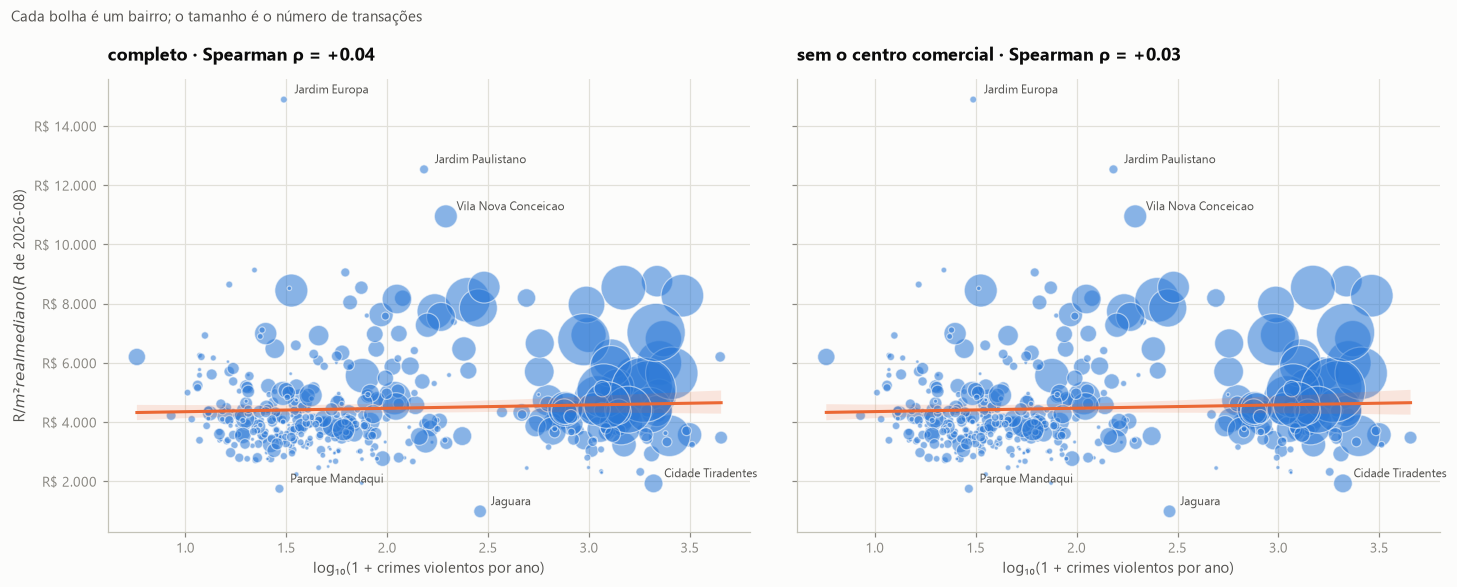

In [15]:
fig, eixos = plt.subplots(1, 2, figsize=(13.5, 5.4), sharey=True)

for eixo, (cenario, dados) in zip(eixos, CENARIOS.items()):
    sns.regplot(
        data=dados, x="log_violentos", y="preco_m2_mediano", ax=eixo,
        scatter_kws={"s": dados["n_transacoes"] / 6, "alpha": 0.55, "color": AZUL,
                     "linewidths": 0.8, "edgecolor": SUPERFICIE},
        line_kws={"color": LARANJA, "linewidth": 2},
    )
    rho = stats.spearmanr(dados["log_violentos"], dados["preco_m2_mediano"]).statistic
    eixo.set(title=f"{cenario} · Spearman ρ = {rho:+.2f}",
             xlabel="log₁₀(1 + crimes violentos por ano)", ylabel="")
    destaques = [*dados["preco_m2_mediano"].nlargest(3).index, *dados["preco_m2_mediano"].nsmallest(3).index]
    for bairro in destaques:
        linha = dados.loc[bairro]
        eixo.annotate(bairro.title(), (linha["log_violentos"], linha["preco_m2_mediano"]),
                      xytext=(7, 4), textcoords="offset points", fontsize=8, color=TINTA2)

eixos[0].set_ylabel(f"R$/m² real mediano (R$ de {MES_REFERENCIA})")
eixos[0].yaxis.set_major_formatter(FORMATO_REAIS)
fig.suptitle("Cada bolha é um bairro; o tamanho é o número de transações",
             x=0.01, ha="left", color=TINTA2, fontsize=10)
plt.tight_layout()

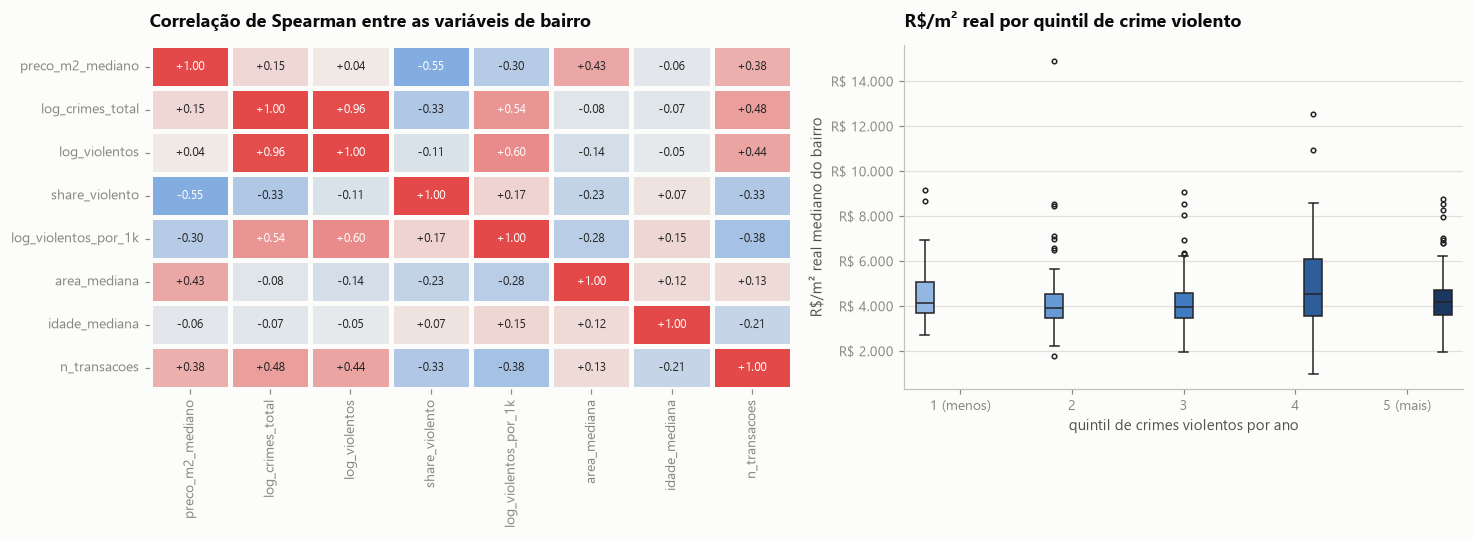

In [16]:
fig, (esq, drt) = plt.subplots(1, 2, figsize=(13.5, 5), width_ratios=[1.15, 1])

colunas = ["preco_m2_mediano", "log_crimes_total", "log_violentos", "share_violento",
           "log_violentos_por_1k", "area_mediana", "idade_mediana", "n_transacoes"]
sns.heatmap(bairros[colunas].corr(method="spearman"), cmap=DIVERGENTE, vmin=-1, vmax=1,
            annot=True, fmt="+.2f", annot_kws={"size": 8}, linewidths=2,
            linecolor=SUPERFICIE, cbar=False, ax=esq)
esq.set_title("Correlação de Spearman entre as variáveis de bairro")

quintis = pd.qcut(bairros["log_violentos"], 5, labels=["1 (menos)", "2", "3", "4", "5 (mais)"])
sns.boxplot(x=quintis, y=bairros["preco_m2_mediano"], hue=quintis, palette=ESCADA_AZUL,
            legend=False, fliersize=3, linewidth=1, ax=drt)
drt.set(title="R$/m² real por quintil de crime violento",
        xlabel="quintil de crimes violentos por ano", ylabel="R$/m² real mediano do bairro")
drt.yaxis.set_major_formatter(FORMATO_REAIS)

plt.tight_layout()

### O que os números dizem

A hipótese se confirma — **mas não na variável que parecia óbvia**. Resultados dos 430 bairros:

| medida de crime | Spearman ρ | p-valor | leitura |
|---|---|---|---|
| crimes totais / ano | **+0,146** | 0,0025 | levemente **positiva** |
| crimes violentos / ano | **+0,036** | 0,46 | nenhuma relação |
| **% de crimes que são violentos** | **−0,548** | 4,5 × 10⁻³⁵ | forte e negativa |
| violentos por mil transações | **−0,296** | 4,0 × 10⁻¹⁰ | moderada e negativa |

Lendo em português: **a quantidade de crime de um bairro não diz nada sobre o preço do metro quadrado — se algo, bairro caro tem mais crime. A natureza do crime diz muito.**

O boxplot por quintil de `% violento` mostra isso de forma limpa e monotônica:

| quintil de % violento | R$/m² real mediano |
|---|---|
| 1 (menos violento) | R$ 5.019 |
| 2 | R$ 4.363 |
| 3 | R$ 4.018 |
| 4 | R$ 3.904 |
| 5 (mais violento) | **R$ 3.480** |

Do quintil menos violento ao mais violento, o metro quadrado cai **31%**, sem inversões no caminho.

A explicação é a distinção entre **exposição** e **risco**, que era a principal ameaça metodológica identificada antes de medir. Jardim Paulistano registra 844 ocorrências por ano e custa R$ 12,5 mil/m² — mas só 18% dessas ocorrências são violentas: é furto, movido por comércio, escritórios e circulação de gente. Cidade Tiradentes registra 3.976 por ano, custa R$ 1,9 mil/m², e 52% são violentas. Os 50 bairros mais caros têm **mais** crime em volume absoluto (2.176 ao ano, contra 1.394 nos 50 mais baratos) e muito menos violência proporcional (30% contra 46%). É a composição que o preço reflete.

Duas observações reforçam o resultado:

1. **Remover o centro comercial quase não muda nada** (ρ de −0,548 para −0,554). Se o efeito viesse do artefato de fluxo de pessoas no centro, teria desabado ao tirar Sé, República, Brás e companhia. Não desabou — então não é artefato do centro.
2. **As duas medidas que normalizam por exposição concordam entre si** (−0,548 e −0,296), e as duas que não normalizam concordam em não achar nada. O padrão é coerente, não um achado isolado.

O custo de ter medido só a contagem bruta, como faz a formulação ingênua da hipótese, teria sido concluir que crime não tem relação com preço de imóvel em São Paulo — ou, pior, que **mais crime acompanha preço mais alto**. As duas conclusões estariam erradas.

## 10 · Base para a modelagem

O perfil criminal do bairro é colado de volta em cada transação. O perfil é **estático** (média anual de 2022–2025) porque a hipótese é espacial — "bairro violento é mais barato" — e não sobre a variação ano a ano do crime, que em quatro anos é pequena frente às diferenças entre bairros.

Dois arquivos são gravados para o notebook 03 não repetir nenhum tratamento. O `preco_m2` gravado já é o deflacionado.

In [17]:
COLUNAS_CRIME = ["crimes_total", "violentos", "share_violento", "violentos_por_1k"]

modelagem = base.merge(bairros[COLUNAS_CRIME], left_on="bairro", right_index=True, how="inner")
modelagem.attrs["mes_referencia"] = MES_REFERENCIA
modelagem.to_parquet(CACHE / "base_modelagem.parquet", index=False)
bairros.to_parquet(CACHE / "bairros.parquet")
(CACHE / "mes_referencia.txt").write_text(MES_REFERENCIA, encoding="utf-8")

print(f"base_modelagem: {len(modelagem):,} transações × {modelagem.shape[1]} colunas")
print(f"bairros:        {len(bairros):,} bairros")
print(f"preços em reais constantes de {MES_REFERENCIA}")

base_modelagem: 312,322 transações × 40 colunas
bairros:        430 bairros
preços em reais constantes de 2026-08


## 10 · Ressalvas

Cinco coisas podem distorcer o que foi medido acima. Nenhuma invalida a análise, mas todas limitam o quanto se pode afirmar.

**1. Crime registrado não é crime ocorrido.** O boletim de ocorrência depende de alguém ir registrar. Bairros de renda mais alta tendem a registrar mais — o que, se for forte, *reduz* a correlação negativa observada em vez de criá-la.

**2. Contagem de crime mede exposição, não só risco.** O cenário "sem o centro comercial" e as medidas de composição (`% violento`) existem para contornar isso, mas nenhuma substitui uma taxa por habitante. A base de população por setor censitário disponível no repositório é do Rio de Janeiro, não de São Paulo, então essa normalização não foi possível.

**3. O valor da transação é declarado pelo contribuinte** e existe incentivo a subdeclarar — é justamente por isso que a Prefeitura usa `max(valor declarado, valor venal de referência)` como base de cálculo do imposto. Se a subdeclaração fosse uniforme pela cidade, ela só desloca o nível e não afeta a correlação; se for mais comum em algum tipo de bairro, enviesa.

**4. Seleção pelo gazetteer.** Uma rua só tem bairro conhecido se alguma ocorrência foi registrada nela, então as transações descartadas se concentram em ruas tranquilas. Isso remove da amostra justamente parte do extremo de "pouco crime", o que tende a **atenuar** a correlação medida.

**5. Correlação não é causalidade.** Mesmo um coeficiente negativo forte é compatível com renda sendo a causa comum: bairros ricos têm simultaneamente imóveis caros e menos crime violento. O notebook 03 ataca essa parte controlando pelas características físicas do imóvel, o que é um controle parcial — não um experimento.

Sobre a deflação: o IPCA é um índice **nacional** de consumo. Ele corrige poder de compra geral, não custo de construção nem dinâmica imobiliária específica de São Paulo. Para a hipótese isso é suficiente, porque a correção é a mesma para todos os bairros no mesmo mês — ela limpa a tendência temporal sem mexer na comparação entre bairros.

➡️ Próximo: `03_modelagem.ipynb`.